This is the presentation of creating the number classifying from start to end with visualization

Shape of data (50000, 28, 28)
Shape of target (50000,)


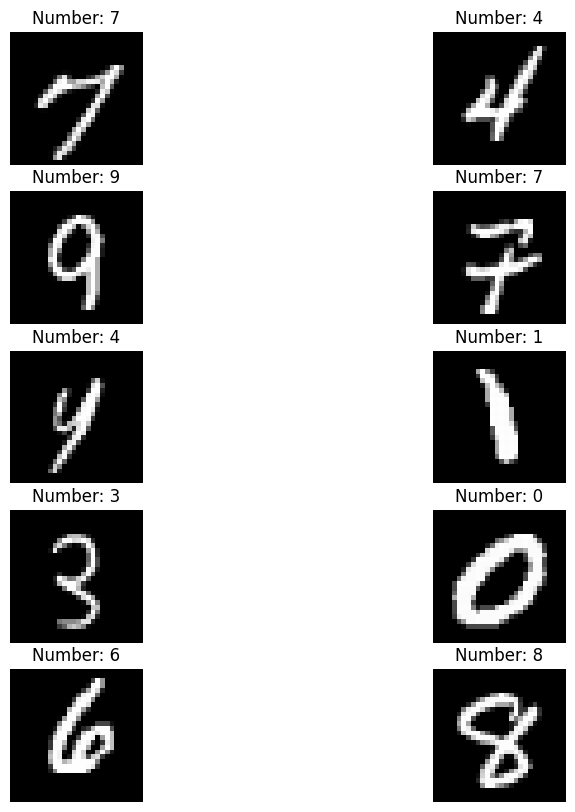

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers # type: ignore
from sklearn.model_selection import train_test_split

# Load data into variable
data = np.load("data/mnist.npz") 

# Extract train, test, file
x_train, x_test, y_train, y_test = data["x_train"], data["x_test"], data["y_train"], data["y_test"]

# Split train and validation for no bias !!!
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=10000, random_state = 194
) # 50k train, 10k validate, 10k testing !


# Convert integer labels to one-hot vectors for better loss function
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=10)
y_val_onehot = keras.utils.to_categorical(y_val, num_classes=10)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=10)

print("Shape of data", x_train.shape)
print("Shape of target", y_train.shape)

#Draw first 10 number in train to see
plt.figure(figsize=(10,10)) #width 10, height 10
for i in range(10):
    plt.subplot(5, 2, i + 1)
    plt.imshow(x_train[i], cmap="gray")  # change cmap if RGB
    plt.title(f"Number: {y_train[i]}")
    plt.axis("off")
plt.show()

Then next, we will define the layer of the model and the compile of the model

In [5]:


# Creating my model
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),   # will turn (28,28) into (784,)

    layers.Dense(128, activation = "relu"), #taking in input,first layer
    layers.Dropout(0.6),

    layers.Dense(16), # second layer, special layer with no activation but will normalize the batch
    layers.BatchNormalization(),

    layers.Dense(32, activation = "relu" ), # third layer
    

    layers.Dense(64, activation = "sigmoid" ), # fourth layer
    layers.Dropout(0.1),

    layers.Dense(10, activation = "softmax") #Result as probabilities of final results
])

#defining optimizer, in this case adam ~ gradient descent
#loss will be mean absolute error
model.compile(
    optimizer = "adam",
    loss ="mean_squared_error",
    metrics=["accuracy"]
)

Next, we will fit the data into the model for it to training, Also to prevent it from start epoch with no stop, add EarlyStopping

In [6]:
from tensorflow.keras.callbacks import EarlyStopping # type: ignore
early_stop = EarlyStopping(
    monitor = "val_loss", 
    patience = 3, # stop if no improvement for 3 epochs
    restore_best_weights = True,  # roll back to the best model
    min_delta = 0.001,   # require at least +0.1% improvement

)



history = model.fit(
    x_train, y_train_onehot, # testing data
    validation_data =(x_val, y_val_onehot), # validation data
    batch_size = 16, # after 32 sample, the optimizer will change the weights
    epochs = 20,
    callbacks =[early_stop],
)

Epoch 1/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7832 - loss: 0.0306 - val_accuracy: 0.9311 - val_loss: 0.0107
Epoch 2/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.8776 - loss: 0.0187 - val_accuracy: 0.9423 - val_loss: 0.0091
Epoch 3/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.8911 - loss: 0.0167 - val_accuracy: 0.9455 - val_loss: 0.0084
Epoch 4/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9000 - loss: 0.0155 - val_accuracy: 0.9494 - val_loss: 0.0079
Epoch 5/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - accuracy: 0.9076 - loss: 0.0144 - val_accuracy: 0.9527 - val_loss: 0.0073
Epoch 6/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - accuracy: 0.9120 - loss: 0.0137 - val_accuracy: 0.9553 - val_loss: 0.0070
Epoch 7/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9133 - loss: 0.0135 - val_accuracy: 0.9522 - val_loss: 0.0075


A better way to view the loss though is to plot it. The fit method in fact keeps a record of the loss produced during training in a History object. We'll convert the data to a Pandas dataframe, which makes the plotting easy.

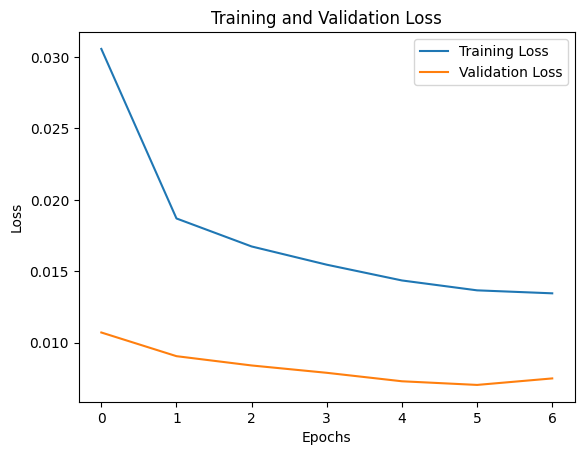

In [7]:
import pandas as pd
# convert the training history to a dataframe
history_df = pd.DataFrame(history.history)
# use Pandas native plot method
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Checking the accuracy of the model on test data:

In [8]:
loss, accuracy = model.evaluate(x_test, y_test_onehot, verbose=1)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9514 - loss: 0.0075
Test Loss: 0.0075
Test Accuracy: 0.9514


After training, we have initial training weight already, but to stop from start again over and over again, we save the model totally into a new file and use it again for production.

In [9]:
model.save("final_model/NNmodelver4.keras")
model.save("final_model/NNmodelver4.h5") 